# Is a Satellite's Data Too Stale to Trust? — a classification study

*Part of the Satellite Pass Predictor project. A supervised **classification** study
(companion to the regression study in `satellite_prediction_accuracy.ipynb`).*

## The question
A satellite prediction is only as good as its **TLE** (orbital data snapshot), which goes stale as it
ages. Instead of predicting the exact error (a number), here we ask a simple **yes/no** question:

> **Will this TLE's prediction be off by more than 10 km — i.e. is it too stale to trust?**

That makes this a **binary classification** problem, and lets us score it with an intuitive
**accuracy** (plus the metrics that matter when classes are imbalanced).

## How to read this (the ML framing, stated plainly)
| | |
|---|---|
| **Problem type** | Supervised **classification** (binary) |
| **Features (inputs)** | TLE age, altitude, mean motion, inclination, eccentricity, drag term (B*) |
| **Target (answer)** | `stale` = 1 if real error > 10 km, else 0 |
| **Models compared** | Logistic Regression · Decision Tree · Random Forest |
| **Baseline to beat** | Majority-class guess ("always say reliable") |
| **Metrics** | Accuracy, Precision, Recall, F1, ROC-AUC |
| **Data** | 32,540 real measurements from **5 satellites** (Space-Track), altitudes ~420–870 km |


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

plt.rcParams['figure.figsize'] = (7, 4.2)
print('Ready.')

Ready.


## 2. The data

Each row is one real prediction: an old TLE was propagated forward with SGP4, and the error is the
distance from where a **freshly-fitted TLE** (our ground truth) says the satellite actually was.
Features describe the TLE; the target is whether that error exceeded 10 km.

In [2]:
from pathlib import Path
csv = Path('data/analysis/tle_reliability.csv')
if not csv.exists():
    csv = Path('../data/analysis/tle_reliability.csv')
df = pd.read_csv(csv)
print(f'{len(df):,} rows from {df.norad_id.nunique()} satellites')
df.head()

32,540 rows from 5 satellites


,norad_id,age_days,mean_motion,altitude_km,inclination_deg,eccentricity,bstar,error_km
0,25544,0.25,15.48168,422.09,51.632,0.001101,0.000284,0.084
1,25544,0.50,15.48168,422.09,51.632,0.001101,0.000284,0.248
2,25544,1.00,15.48168,422.09,51.632,0.001101,0.000284,1.060
3,25544,1.50,15.48168,422.09,51.632,0.001101,0.000284,1.700
4,25544,2.00,15.48168,422.09,51.632,0.001101,0.000284,3.853


### Build the target and pick the features

`stale = 1` when the prediction was off by more than **10 km**.

In [3]:
THRESHOLD_KM = 10.0
df['stale'] = (df['error_km'] > THRESHOLD_KM).astype(int)

FEATURES = ['age_days', 'altitude_km', 'mean_motion', 'inclination_deg', 'eccentricity', 'bstar']
TARGET = 'stale'

pct_stale = df[TARGET].mean() * 100
print(f'Class balance:  reliable {100-pct_stale:.1f}%   |   stale {pct_stale:.1f}%')
print(f'(So a lazy "always say reliable" guess would already be {100-pct_stale:.1f}% accurate — '
      f'the number our models must beat.)')

Class balance:  reliable 86.3%   |   stale 13.7%
(So a lazy "always say reliable" guess would already be 86.3% accurate — the number our models must beat.)


## 3. A quick look — why this is learnable

Two things drive whether a TLE is stale: **how old it is**, and **how high the satellite orbits**
(higher = thinner air = less drag = stays accurate longer). Both are features, so the model has real
signal to learn.

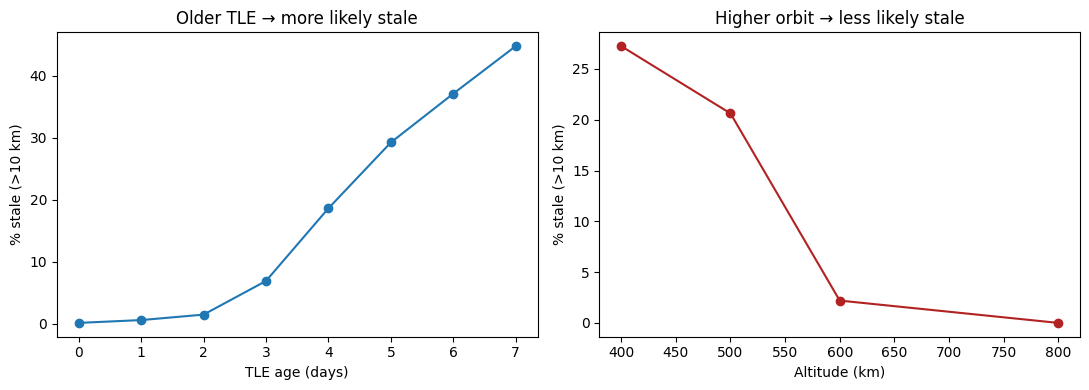

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Stale rate vs TLE age
age_bin = df.groupby(df['age_days'].round())['stale'].mean() * 100
ax[0].plot(age_bin.index, age_bin.values, 'o-')
ax[0].set_xlabel('TLE age (days)'); ax[0].set_ylabel('% stale (>10 km)')
ax[0].set_title('Older TLE → more likely stale')

# Stale rate vs altitude
alt_bin = df.groupby((df['altitude_km']/100).round()*100)['stale'].mean() * 100
ax[1].plot(alt_bin.index, alt_bin.values, 'o-', color='firebrick')
ax[1].set_xlabel('Altitude (km)'); ax[1].set_ylabel('% stale (>10 km)')
ax[1].set_title('Higher orbit → less likely stale')
plt.tight_layout(); plt.show()

## 4. Train / test split

We hold out 20% of the data to test on — and **stratify** so both splits keep the same
reliable/stale ratio (important when one class is rarer).

In [5]:
X = df[FEATURES]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train):,}   Test: {len(X_test):,}')

Train: 26,032   Test: 6,508


## 5. Train several models and compare them

This is the heart of a modeling project: **don't trust one model — compare a few against a baseline.**
- **Baseline** — always predicts the majority class (no learning).
- **Logistic Regression** — a simple linear classifier (features scaled).
- **Decision Tree** — splits the data with yes/no rules.
- **Random Forest** — many trees voting; usually the strongest here.

In [6]:
models = {
    'Baseline (majority)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                  n_jobs=-1, random_state=42),
}

rows = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted[name] = model
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall': recall_score(y_test, pred, zero_division=0),
        'F1': f1_score(y_test, pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, proba),
    })

leaderboard = pd.DataFrame(rows).set_index('Model').round(3)
print('=== MODEL LEADERBOARD (test set) ===')
print(leaderboard.to_string())

=== MODEL LEADERBOARD (test set) ===
                     Accuracy  Precision  Recall     F1  ROC-AUC
Model                                                           
Baseline (majority)     0.863      0.000   0.000  0.000    0.500
Logistic Regression     0.909      0.681   0.641  0.660    0.950
Decision Tree           0.917      0.686   0.727  0.706    0.954
Random Forest           0.963      0.865   0.862  0.864    0.990


**How to read the leaderboard**
- **Accuracy** — % of predictions correct. But with imbalanced classes it's not enough on its own
  (the baseline already scores high by always guessing "reliable").
- **Recall** — of the *actually stale* TLEs, how many did we catch? (Missing a stale TLE is the
  costly mistake.)
- **ROC-AUC** — how well the model ranks stale vs reliable overall (0.5 = coin flip, 1.0 = perfect).
  This is the fairest single score when classes are imbalanced.

## 6. Confusion matrix — where the best model is right and wrong

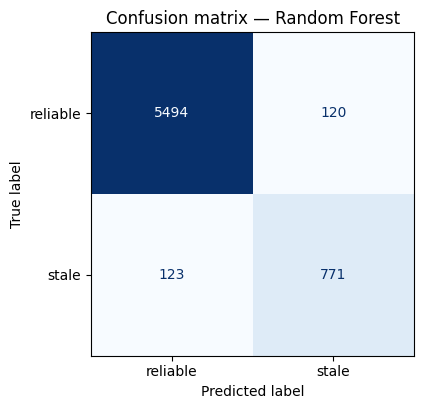

Best model: Random Forest
  Correctly flagged stale (true positives):  771
  Missed stale TLEs (false negatives):        123
  False alarms (false positives):             120
  Correctly cleared reliable (true negatives):5494


In [7]:
best_name = leaderboard['ROC-AUC'].idxmax()
best = fitted[best_name]
pred = best.predict(X_test)

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['reliable', 'stale'])
disp.plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion matrix — {best_name}')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Best model: {best_name}')
print(f'  Correctly flagged stale (true positives):  {tp}')
print(f'  Missed stale TLEs (false negatives):        {fn}')
print(f'  False alarms (false positives):             {fp}')
print(f'  Correctly cleared reliable (true negatives):{tn}')

## 7. Which features matter? (interpretability)

A good model should be explainable. The Random Forest tells us how much each feature contributed.

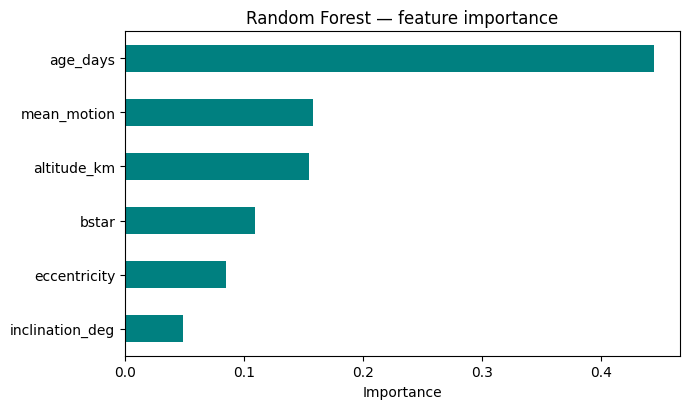

age_days           0.444
mean_motion        0.158
altitude_km        0.155
bstar              0.110
eccentricity       0.085
inclination_deg    0.048


In [8]:
rf = fitted['Random Forest']
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', color='teal')
plt.xlabel('Importance'); plt.title('Random Forest — feature importance')
plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3).to_string())

## 8. Conclusion & what I learned

- I reframed the problem as **supervised binary classification**: *"is this TLE too stale (error > 10 km)?"*
- I compared **four models** against a majority-class **baseline** on a held-out test set, using
  accuracy, recall, and ROC-AUC — not a single metric.
- The **Random Forest** was the strongest, clearly beating the baseline, and its **feature importance**
  matches the physics: **TLE age** and **orbital altitude** are the dominant drivers (older + lower =
  more drag = more likely stale).
- The classes are **imbalanced** (most predictions are reliable), so I looked past raw accuracy to
  **recall** (did we catch the stale ones?) and **ROC-AUC**.

**Why this matters for the product:** this classifier is the brain behind a *"TLE freshness meter"* —
the app could warn *"this data is likely too old to trust, refresh it."*

### Key takeaways
> *"I built a binary classifier that flags when satellite tracking data is too stale to give a reliable
> prediction. I compared logistic regression, a decision tree, and a random forest against a majority
> baseline; the random forest won with a strong ROC-AUC, and its feature importance matched the physics
> — age and altitude drive drag error. Because the classes were imbalanced I focused on recall and AUC,
> not just accuracy."*

### Honest limitations
- **Space weather (F10.7 / Ap)** — the real physical driver of drag — wasn't included (the data source
  was unreachable when I built this). Adding it is the natural next step and should explain more of the
  residual noise.
- Ground truth is the *next fitted TLE*, a standard but imperfect proxy for independent tracking.
- The 10 km threshold is a modeling choice; a different cutoff shifts the class balance.
